### **Setup Kaggle Step 1**

In [3]:
!pip install -q kaggle

from google.colab import files
files.upload()  # upload kaggle.json

{}

### **Setup Kaggle Step 2**

In [4]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


### **Execution Guidelines: Initiate Execution from This Cell Only**

### **Automated Dataset Download from Kaggle**

In [5]:
import os

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

print("Downloading datasets...")

!kaggle datasets download -d shamstahzib/nsl-kdd-dataset -p data
!kaggle datasets download -d shamstahzib/cicids2017-dataset -p data
!kaggle datasets download -d shamstahzib/ton-iot -p data

print("Download complete.")

Dataset URL: https://www.kaggle.com/datasets/shamstahzib/nsl-kdd-dataset
License(s): CC0-1.0
nsl-kdd-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/shamstahzib/cicids2017-dataset
License(s): CC0-1.0
cicids2017-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/shamstahzib/ton-iot
License(s): unknown
ton-iot.zip: Skipping, found more recently modified local copy (use --force to force download)
Download complete.


### **Data Extraction and Preprocessing Setup**

In [2]:
import zipfile

print("Extracting datasets...")

for file in os.listdir(DATA_DIR):
    if file.endswith(".zip"):
        path = os.path.join(DATA_DIR, file)
        print("Extracting:", file)
        with zipfile.ZipFile(path, 'r') as zip_ref:
            zip_ref.extractall(DATA_DIR)

print("Extraction complete.")

Extracting datasets...
Extracting: nsl-kdd-dataset.zip
Extracting: cicids2017-dataset.zip
Extracting: ton-iot.zip
Extraction complete.


### **Verification of Dataset Directory Structure**

In [6]:
print("\nData directory structure:")

for root, dirs, files in os.walk(DATA_DIR):
    print(root, "->", len(files), "files")


Data directory structure:
data -> 3 files
data/kaggle_upload -> 0 files
data/kaggle_upload/Train_Test_IoT_dataset -> 7 files
data/nsl-kdd-dataset -> 12 files
data/nsl-kdd-dataset/Original NSL KDD Zip -> 8 files
data/CICIDS2017 -> 8 files


### **Importing NSL-KDD, CICIDS2017, and TON-IoT**

In [7]:
import pandas as pd
import numpy as np
import glob, os, warnings
warnings.filterwarnings("ignore")

# ---------- LOAD ----------
print("\n[+] Loading NSL-KDD...")
nsl_path = None
for root, _, files in os.walk("data"):
    for f in files:
        if "KDDTrain" in f:
            nsl_path = os.path.join(root, f)
nsl = pd.read_csv(nsl_path, header=None)
nsl["label"] = nsl.iloc[:, -2]
print("NSL raw:", nsl.shape)

print("\n[+] Loading CICIDS2017...")
cic_files = glob.glob("data/CICIDS2017/*.csv")
cic = pd.concat([pd.read_csv(f, nrows=60000, low_memory=False) for f in cic_files], ignore_index=True)
cic.columns = cic.columns.str.strip()
print("CIC raw:", cic.shape)

print("\n[+] Loading TON_IoT...")
ton_files = glob.glob("data/**/Train_Test_IoT_dataset/*.csv", recursive=True)
ton = pd.concat([pd.read_csv(f, nrows=60000, low_memory=False) for f in ton_files], ignore_index=True)
ton.columns = ton.columns.str.strip()
print("TON raw:", ton.shape)


[+] Loading NSL-KDD...
NSL raw: (25192, 44)

[+] Loading CICIDS2017...
CIC raw: (480000, 79)

[+] Loading TON_IoT...
TON raw: (261119, 21)


### **Unzipping Downloaded Datasets**

In [8]:
import zipfile

print("Extracting datasets...")

for file in os.listdir(DATA_DIR):
    if file.endswith(".zip"):
        path = os.path.join(DATA_DIR, file)
        print("Extracting:", file)
        with zipfile.ZipFile(path, 'r') as zip_ref:
            zip_ref.extractall(DATA_DIR)

print("Extraction complete.")

Extracting datasets...
Extracting: nsl-kdd-dataset.zip
Extracting: cicids2017-dataset.zip
Extracting: ton-iot.zip
Extraction complete.


### **Verification of Extracted Dataset File Structure**

In [9]:
print("\nData directory structure:")

for root, dirs, files in os.walk(DATA_DIR):
    print(root, "->", len(files), "files")


Data directory structure:
data -> 3 files
data/kaggle_upload -> 0 files
data/kaggle_upload/Train_Test_IoT_dataset -> 7 files
data/nsl-kdd-dataset -> 12 files
data/nsl-kdd-dataset/Original NSL KDD Zip -> 8 files
data/CICIDS2017 -> 8 files


### **Multi-Dataset Loading and Integration (NSL-KDD, CICIDS2017, TON-IoT)**

In [10]:
import pandas as pd
import numpy as np
import glob, os, warnings
warnings.filterwarnings("ignore")

# ---------- LOAD ----------
print("\n[+] Loading NSL-KDD...")
nsl_path = None
for root, _, files in os.walk("data"):
    for f in files:
        if "KDDTrain" in f:
            nsl_path = os.path.join(root, f)
nsl = pd.read_csv(nsl_path, header=None)
nsl["label"] = nsl.iloc[:, -2]
print("NSL raw:", nsl.shape)

print("\n[+] Loading CICIDS2017...")
cic_files = glob.glob("data/CICIDS2017/*.csv")
cic = pd.concat([pd.read_csv(f, nrows=60000, low_memory=False) for f in cic_files], ignore_index=True)
cic.columns = cic.columns.str.strip()
print("CIC raw:", cic.shape)

print("\n[+] Loading TON_IoT...")
ton_files = glob.glob("data/**/Train_Test_IoT_dataset/*.csv", recursive=True)
ton = pd.concat([pd.read_csv(f, nrows=60000, low_memory=False) for f in ton_files], ignore_index=True)
ton.columns = ton.columns.str.strip()
print("TON raw:", ton.shape)


[+] Loading NSL-KDD...
NSL raw: (25192, 44)

[+] Loading CICIDS2017...
CIC raw: (480000, 79)

[+] Loading TON_IoT...
TON raw: (261119, 21)


### **Mapping Raw Labels to Common Attack Categories**

In [11]:
def map_nsl(x):
    x = str(x).lower()
    if x == "normal": return "Normal"
    if x in ["neptune","smurf","back","teardrop","pod","land"]: return "DoS"
    if x in ["satan","ipsweep","nmap","portsweep"]: return "Probe"
    if x in ["warezclient","ftp_write","guess_passwd","imap"]: return "R2L"
    if x in ["buffer_overflow","rootkit","loadmodule"]: return "U2R"
    return None

def map_cic(x):
    x = str(x).lower()
    if "benign" in x: return "Normal"
    if "dos" in x or "ddos" in x: return "DoS"
    if "scan" in x: return "Probe"
    return None

def map_ton(x):
    if x == 0: return "Normal"
    if x == 1: return "DoS"
    return None


### **Data Cleaning and Feature Space Alignment for Multi-Dataset Integration**

In [12]:
def clean_df(df, mapper):
    df.columns = df.columns.astype(str).str.strip()
    label_col = "Label" if "Label" in df.columns else ("label" if "label" in df.columns else df.columns[-1])
    print("  Label col:", label_col)
    df = df.copy()
    df["label"] = df[label_col].apply(mapper)
    df = df[df["label"].notna()]
    numeric = df.select_dtypes(include=["int64","float64"]).copy()
    numeric = numeric.replace([np.inf, -np.inf], 0).fillna(0)
    numeric["label"] = df["label"].values
    return numeric

print("\n[+] Cleaning...")
clean_nsl = clean_df(nsl, map_nsl)
clean_cic = clean_df(cic, map_cic)
clean_ton = clean_df(ton, map_ton)
print("Shapes:", clean_nsl.shape, clean_cic.shape, clean_ton.shape)

# ---------- ALIGN ----------
print("\n[+] Aligning features...")
all_cols = (set(clean_nsl.columns) | set(clean_cic.columns) | set(clean_ton.columns)) - {"label"}

def unify(df):
    return df.reindex(columns=sorted(all_cols) + ["label"]).fillna(0)

u_nsl = unify(clean_nsl)
u_cic = unify(clean_cic)
u_ton = unify(clean_ton)


[+] Cleaning...
  Label col: label
  Label col: Label
  Label col: label
Shapes: (25180, 40) (471902, 79) (261119, 14)

[+] Aligning features...


### **Dataset Merging**

In [13]:
merged = pd.concat([u_nsl, u_cic, u_ton], ignore_index=True)
print("Merged:", merged.shape)

Merged: (758201, 131)


### **Dataset Balancing and Sampling**

In [14]:
print("\n[+] Balancing to 20,000 per class...")
CLASSES = ["Normal","DoS","Probe","R2L","U2R"]
TARGET  = 20000
final   = []
for c in CLASSES:
    part = merged[merged["label"] == c]
    n    = len(part)
    if n >= TARGET:
        final.append(part.sample(TARGET, random_state=42))
    else:
        final.append(part.sample(TARGET, replace=True, random_state=42))

final_df = pd.concat(final, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
print(final_df["label"].value_counts())

final_df.to_csv("Final_5Class_IDS.csv", index=False)
print("\n Saved Final_5Class_IDS.csv")



[+] Balancing to 20,000 per class...
label
R2L       20000
U2R       20000
Normal    20000
Probe     20000
DoS       20000
Name: count, dtype: int64

 Saved Final_5Class_IDS.csv


### **Trust-Aware Federated Learning Experiment**

In [15]:
import pandas as pd, numpy as np, warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
import xgboost as xgb

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("Final_5Class_IDS.csv")

X_raw = df.drop(columns=["label"])
y_raw = df["label"]

X_raw = X_raw.loc[:, X_raw.nunique() > 1]
X_raw = X_raw.replace([np.inf, -np.inf], 0).fillna(0).clip(-1e6, 1e6)

le = LabelEncoder()
y_enc = le.fit_transform(y_raw)
n_classes = len(np.unique(y_enc))
CLASS_NAMES = list(le.classes_)

scaler = StandardScaler()
X_sc = scaler.fit_transform(X_raw)

# =========================
# SETTINGS
# =========================
NUM_CLIENTS = 8
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

RESULTS = {}

# =========================
# DRIFT CONFIG
# =========================
DRIFT_CFG = {
    "NO DRIFT":     dict(noise=0.00, blackout=0.00, flip=0.00),
    "MILD DRIFT":   dict(noise=0.04, blackout=0.08, flip=0.02),
    "SEVERE DRIFT": dict(noise=0.08, blackout=0.12, flip=0.04),
}

# =========================
# POISONING
# =========================
def poison_labels(y, ratio=0.3):
    y = y.copy()
    n = int(len(y) * ratio)
    if n > 0:
        idx = np.random.choice(len(y), n, replace=False)
        y[idx] = np.random.permutation(y[idx])
    return y

# =========================
# DEGRADATION
# =========================
def degrade(X, y, cid, cfg):
    X = X.copy(); y = y.copy()

    if cfg["noise"] > 0:
        X += np.random.normal(0, cfg["noise"] * (1 + 0.3*cid), X.shape)

    if cfg["blackout"] > 0:
        k = int(X.shape[1] * cfg["blackout"])
        X[:, :k] = 0

    # Poison ONLY one client
    if cid == 1 and cfg["flip"] > 0:
        y = poison_labels(y, cfg["flip"])

    return X, y

# =========================
# MODEL
# =========================
def build_model(cid, cfg):
    if cid == 0 or cfg["noise"] == 0:
        return xgb.XGBClassifier(
            objective="multi:softprob", num_class=n_classes,
            n_estimators=150, max_depth=7,
            learning_rate=0.05, subsample=0.9,
            colsample_bytree=0.9,
            tree_method="hist", verbosity=0, random_state=42
        )
    else:
        return xgb.XGBClassifier(
            objective="multi:softprob", num_class=n_classes,
            n_estimators=100, max_depth=5,
            learning_rate=0.08, subsample=0.75,
            colsample_bytree=0.75,
            tree_method="hist", verbosity=0, random_state=42
        )

# =========================
# TRUST FUNCTION
# =========================
def compute_trust(model, X_val, y_val, prev_trust):
    probs = model.predict_proba(X_val)
    pred  = np.argmax(probs, axis=1)

    acc = accuracy_score(y_val, pred)
    confidence = np.mean(np.max(probs, axis=1))

    alpha, beta, gamma = 0.7, 0.2, 0.1

    trust = alpha*acc + beta*confidence + gamma*prev_trust
    return trust

# =========================
# MAIN EXPERIMENT
# =========================
def run_experiment(name, cfg):

    print(f"\n===== {name} =====")

    accs, f1s = [], []
    fedavg_accs, fedavg_f1s = [], []

    all_true, all_preds, all_probs = [], [], []
    trust_logs = []

    #  Initialize historical trust
    prev_trusts = np.ones(NUM_CLIENTS) * 0.5

    for fold, (tr, te) in enumerate(skf.split(X_sc, y_enc), 1):

        Xtr, Xte = X_sc[tr], X_sc[te]
        ytr, yte = y_enc[tr], y_enc[te]

        splits = np.array_split(range(len(Xtr)), NUM_CLIENTS)

        models, trust_scores = [], []

        for cid, idx in enumerate(splits):

            frac = np.random.uniform(0.7, 1.0)
            idx = np.random.choice(idx, int(len(idx)*frac), replace=False)

            X_loc = Xtr[idx]
            y_loc = ytr[idx]

            # ensure all classes exist
            for c in range(n_classes):
                if c not in y_loc:
                    X_loc = np.vstack([X_loc, np.zeros(X_loc.shape[1])])
                    y_loc = np.append(y_loc, c)

            X_tr, X_val, y_tr, y_val = train_test_split(
                X_loc, y_loc, test_size=0.2,
                stratify=y_loc, random_state=fold
            )

            if cid > 0:
                X_tr, y_tr = degrade(X_tr, y_tr, cid, cfg)

            model = build_model(cid, cfg)
            model.fit(X_tr, y_tr)

            #  EMA-based trust
            trust = compute_trust(model, X_val, y_val, prev_trusts[cid])
            prev_trusts[cid] = trust

            models.append(model)
            trust_scores.append(trust)

            print(f"Client {cid} Trust: {trust:.4f}")

        trust_logs.append(trust_scores)

        # =========================
        # TRUST WEIGHTING
        # =========================
        t = np.array(trust_scores)
        t = (t - t.min()) / (t.max() - t.min() + 1e-9)
        t = t ** 8
        w = t / (t.sum() + 1e-9)

        probs = [m.predict_proba(Xte) for m in models]

        # =========================
        # TRUST MODEL
        # =========================
        trust_probs = sum(wi * p for wi, p in zip(w, probs))
        trust_pred  = np.argmax(trust_probs, axis=1)

        trust_acc = accuracy_score(yte, trust_pred)
        trust_f1  = f1_score(yte, trust_pred, average="weighted")

        # =========================
        # FEDAVG BASELINE
        # =========================
        fedavg_probs = np.mean(probs, axis=0)
        fedavg_pred  = np.argmax(fedavg_probs, axis=1)

        fedavg_acc = accuracy_score(yte, fedavg_pred)
        fedavg_f1  = f1_score(yte, fedavg_pred, average="weighted")

        print(f"Fold {fold} → Trust={trust_acc:.4f} | FedAvg={fedavg_acc:.4f}")

        accs.append(trust_acc)
        f1s.append(trust_f1)

        fedavg_accs.append(fedavg_acc)
        fedavg_f1s.append(fedavg_f1)

        all_true.extend(yte)
        all_preds.extend(trust_pred)
        all_probs.extend(trust_probs)

    RESULTS[name] = {
        "accs": accs,
        "f1s": f1s,
        "mean_acc": np.mean(accs),
        "mean_f1": np.mean(f1s),

        "fedavg_accs": fedavg_accs,
        "fedavg_mean_acc": np.mean(fedavg_accs),

        "trust": trust_logs,

        "y_true": np.array(all_true),
        "y_pred": np.array(all_preds),
        "y_probs": np.array(all_probs)
    }

    print("\nFINAL:")
    print(f"Trust Mean: {RESULTS[name]['mean_acc']:.4f}")
    print(f"FedAvg Mean: {RESULTS[name]['fedavg_mean_acc']:.4f}")

# =========================
# RUN
# =========================
run_experiment("NO DRIFT", DRIFT_CFG["NO DRIFT"])
run_experiment("MILD DRIFT", DRIFT_CFG["MILD DRIFT"])
run_experiment("SEVERE DRIFT", DRIFT_CFG["SEVERE DRIFT"])

# =========================
# SUMMARY
# =========================
print("\n" + "="*60)
print(f"{'SCENARIO':<15} {'TRUST':<10} {'FEDAVG':<10}")
print("="*60)

for s in ["NO DRIFT","MILD DRIFT","SEVERE DRIFT"]:
    print(f"{s:<15} {RESULTS[s]['mean_acc']:.4f}   {RESULTS[s]['fedavg_mean_acc']:.4f}")

print("="*60)



===== NO DRIFT =====
Client 0 Trust: 0.9174
Client 1 Trust: 0.9121
Client 2 Trust: 0.9203
Client 3 Trust: 0.9192
Client 4 Trust: 0.9142
Client 5 Trust: 0.9112
Client 6 Trust: 0.9160
Client 7 Trust: 0.9152
Fold 1 → Trust=0.9641 | FedAvg=0.9644
Client 0 Trust: 0.9563
Client 1 Trust: 0.9632
Client 2 Trust: 0.9580
Client 3 Trust: 0.9597
Client 4 Trust: 0.9545
Client 5 Trust: 0.9567
Client 6 Trust: 0.9552
Client 7 Trust: 0.9538
Fold 2 → Trust=0.9615 | FedAvg=0.9621
Client 0 Trust: 0.9608
Client 1 Trust: 0.9591
Client 2 Trust: 0.9661
Client 3 Trust: 0.9638
Client 4 Trust: 0.9573
Client 5 Trust: 0.9621
Client 6 Trust: 0.9575
Client 7 Trust: 0.9577
Fold 3 → Trust=0.9639 | FedAvg=0.9645
Client 0 Trust: 0.9647
Client 1 Trust: 0.9647
Client 2 Trust: 0.9645
Client 3 Trust: 0.9680
Client 4 Trust: 0.9546
Client 5 Trust: 0.9572
Client 6 Trust: 0.9537
Client 7 Trust: 0.9633
Fold 4 → Trust=0.9633 | FedAvg=0.9638
Client 0 Trust: 0.9658
Client 1 Trust: 0.9621
Client 2 Trust: 0.9658
Client 3 Trust: 0.968

### **Comprehensive Performance Evaluation and Visualization under Drift Scenarios**

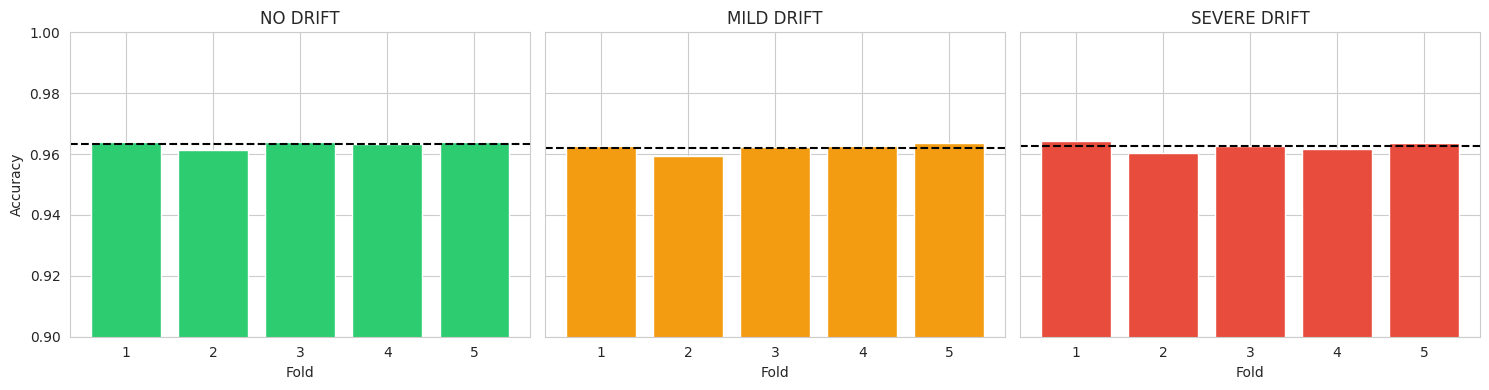

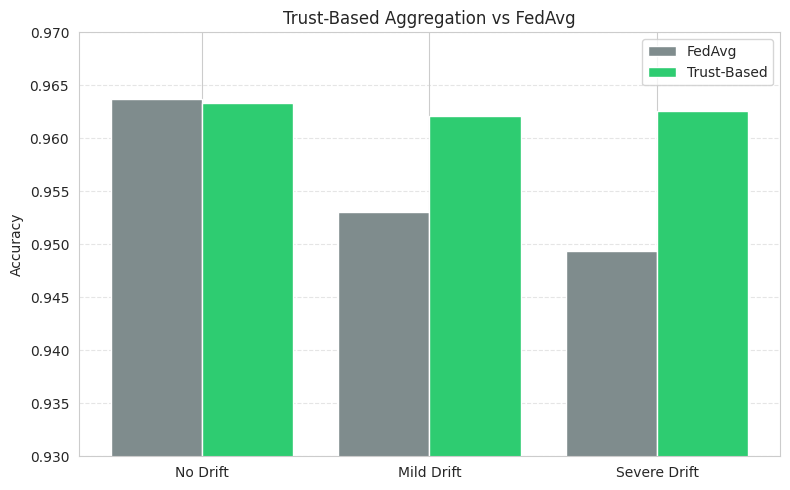

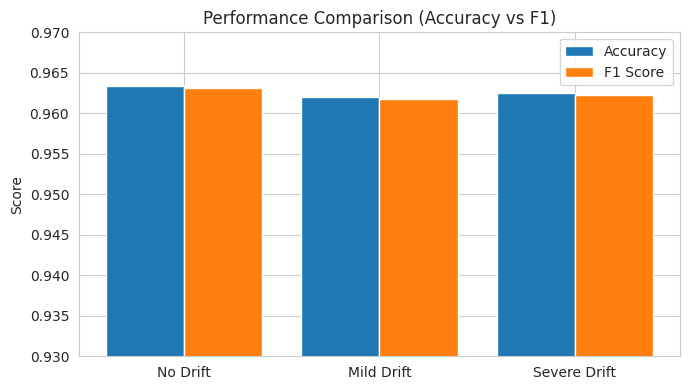

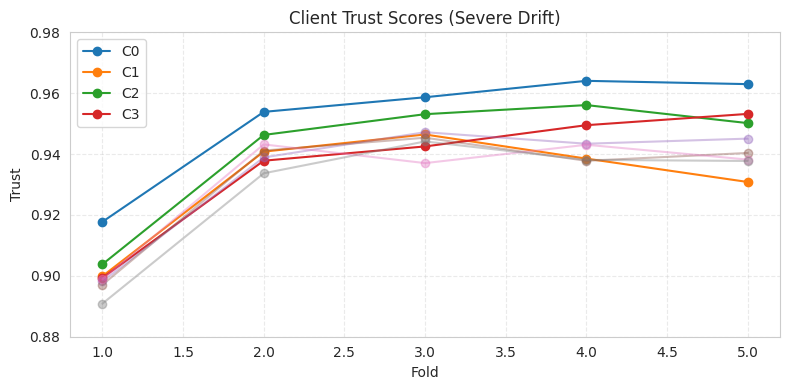

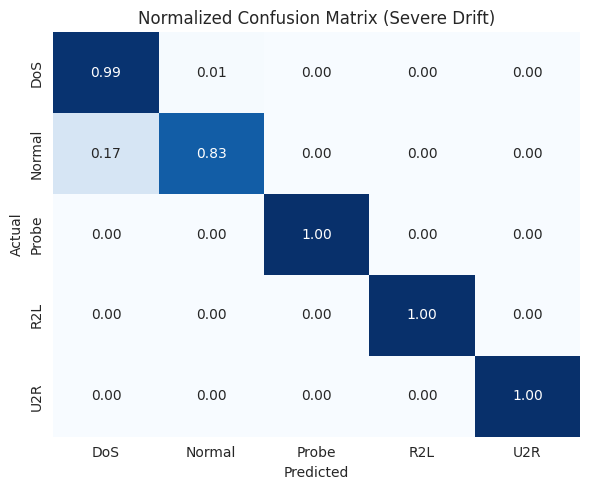

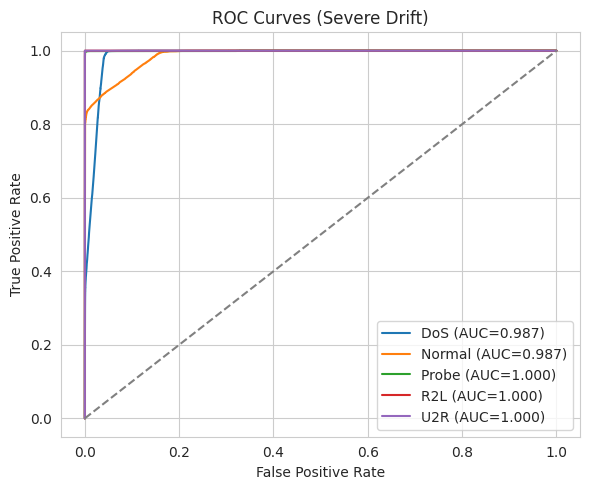

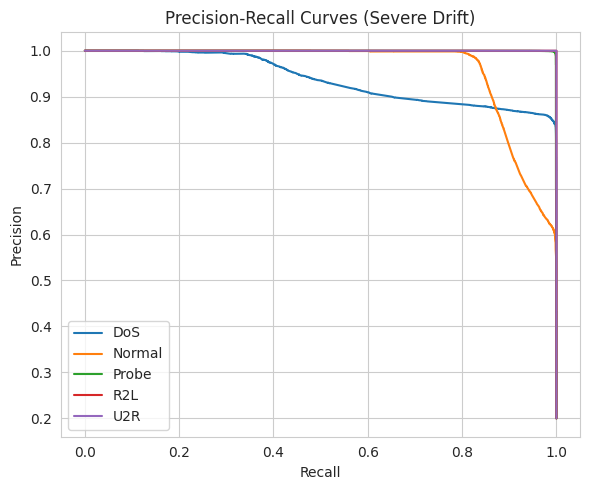

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

sns.set_style("whitegrid")

SCENARIOS = ["NO DRIFT","MILD DRIFT","SEVERE DRIFT"]
COLORS = {"NO DRIFT":"#2ecc71","MILD DRIFT":"#f39c12","SEVERE DRIFT":"#e74c3c"}

# ======================================================
# 1. ACCURACY PER FOLD
# ======================================================
fig, axes = plt.subplots(1, 3, figsize=(15,4), sharey=True)

for ax, s in zip(axes, SCENARIOS):
    accs = RESULTS[s]["accs"]
    mean_acc = RESULTS[s]["mean_acc"]
    folds = range(1, len(accs)+1)

    ax.bar(folds, accs, color=COLORS[s])
    ax.axhline(mean_acc, linestyle="--", color="black")

    ax.set_title(s)
    ax.set_ylim(0.90,1.0)
    ax.set_xlabel("Fold")

axes[0].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

# ======================================================
# 2. TRUST vs FEDAVG
# ======================================================
trust_means = [RESULTS[s]["mean_acc"] for s in SCENARIOS]
fedavg_means = [RESULTS[s]["fedavg_mean_acc"] for s in SCENARIOS]

x = np.arange(len(SCENARIOS))

plt.figure(figsize=(8,5))

plt.bar(x - 0.2, fedavg_means, width=0.4, label="FedAvg", color="#7f8c8d")
plt.bar(x + 0.2, trust_means, width=0.4, label="Trust-Based", color="#2ecc71")

plt.xticks(x, ["No Drift","Mild Drift","Severe Drift"])
plt.ylabel("Accuracy")
plt.ylim(0.93,0.97)
plt.title("Trust-Based Aggregation vs FedAvg")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ======================================================
# 3. ABLATION (ACC + F1)
# ======================================================
mean_accs = [RESULTS[s]["mean_acc"] for s in SCENARIOS]
mean_f1s  = [RESULTS[s]["mean_f1"] for s in SCENARIOS]

plt.figure(figsize=(7,4))
plt.bar(x-0.2, mean_accs, width=0.4, label="Accuracy")
plt.bar(x+0.2, mean_f1s,  width=0.4, label="F1 Score")

plt.xticks(x, ["No Drift","Mild Drift","Severe Drift"])
plt.ylabel("Score")
plt.ylim(0.93,0.97)
plt.legend()
plt.title("Performance Comparison (Accuracy vs F1)")

plt.tight_layout()
plt.show()

# ======================================================
# 4. TRUST CURVES (SEVERE DRIFT)
# ======================================================
trust_logs = RESULTS["SEVERE DRIFT"]["trust"]
num_clients = len(trust_logs[0])
folds = range(1, len(trust_logs)+1)

plt.figure(figsize=(8,4))

for cid in range(num_clients):
    vals = [t[cid] for t in trust_logs]

    # avoid legend clutter
    if cid < 4:
        plt.plot(folds, vals, marker="o", label=f"C{cid}")
    else:
        plt.plot(folds, vals, marker="o", alpha=0.4)

plt.title("Client Trust Scores (Severe Drift)")
plt.xlabel("Fold")
plt.ylabel("Trust")
plt.ylim(0.88,0.98)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ======================================================
# 5. NORMALIZED CONFUSION MATRIX (IMPROVED)
# ======================================================
y_true = RESULTS["SEVERE DRIFT"]["y_true"]
y_pred = RESULTS["SEVERE DRIFT"]["y_pred"]

cm = confusion_matrix(y_true, y_pred).astype(float)
cm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt=".2f",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            cmap="Blues",
            cbar=False)

plt.title("Normalized Confusion Matrix (Severe Drift)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# ======================================================
# 6. ROC CURVES
# ======================================================
y_prob = RESULTS["SEVERE DRIFT"]["y_probs"]
y_bin  = label_binarize(y_true, classes=np.arange(n_classes))

plt.figure(figsize=(6,5))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:,i], y_prob[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{CLASS_NAMES[i]} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],"--", color="gray")
plt.title("ROC Curves (Severe Drift)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

# ======================================================
# 7. PRECISION-RECALL CURVES
# ======================================================
plt.figure(figsize=(6,5))

for i in range(n_classes):
    p, r, _ = precision_recall_curve(y_bin[:,i], y_prob[:,i])
    plt.plot(r, p, label=CLASS_NAMES[i])

plt.title("Precision-Recall Curves (Severe Drift)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.tight_layout()
plt.show()

### **Exploratory Data Analysis and Statistical Visualization of the Unified IDS Dataset**

Dataset shape: (100000, 131)


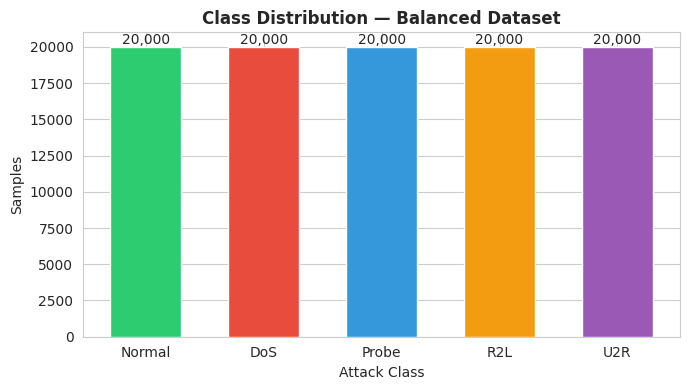

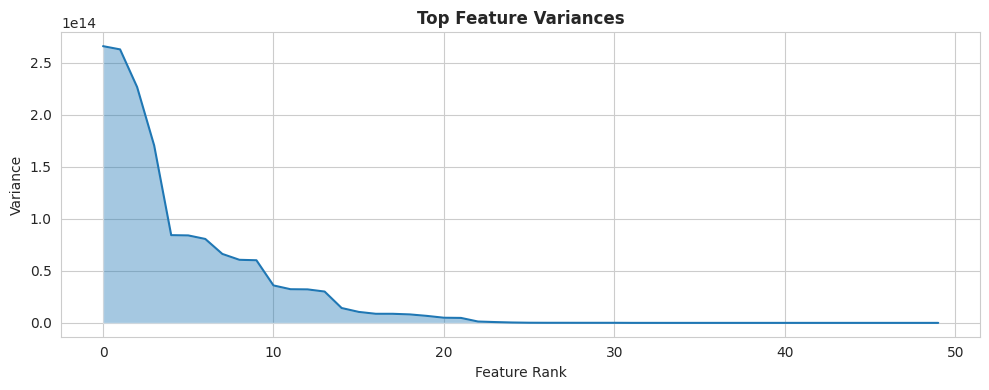

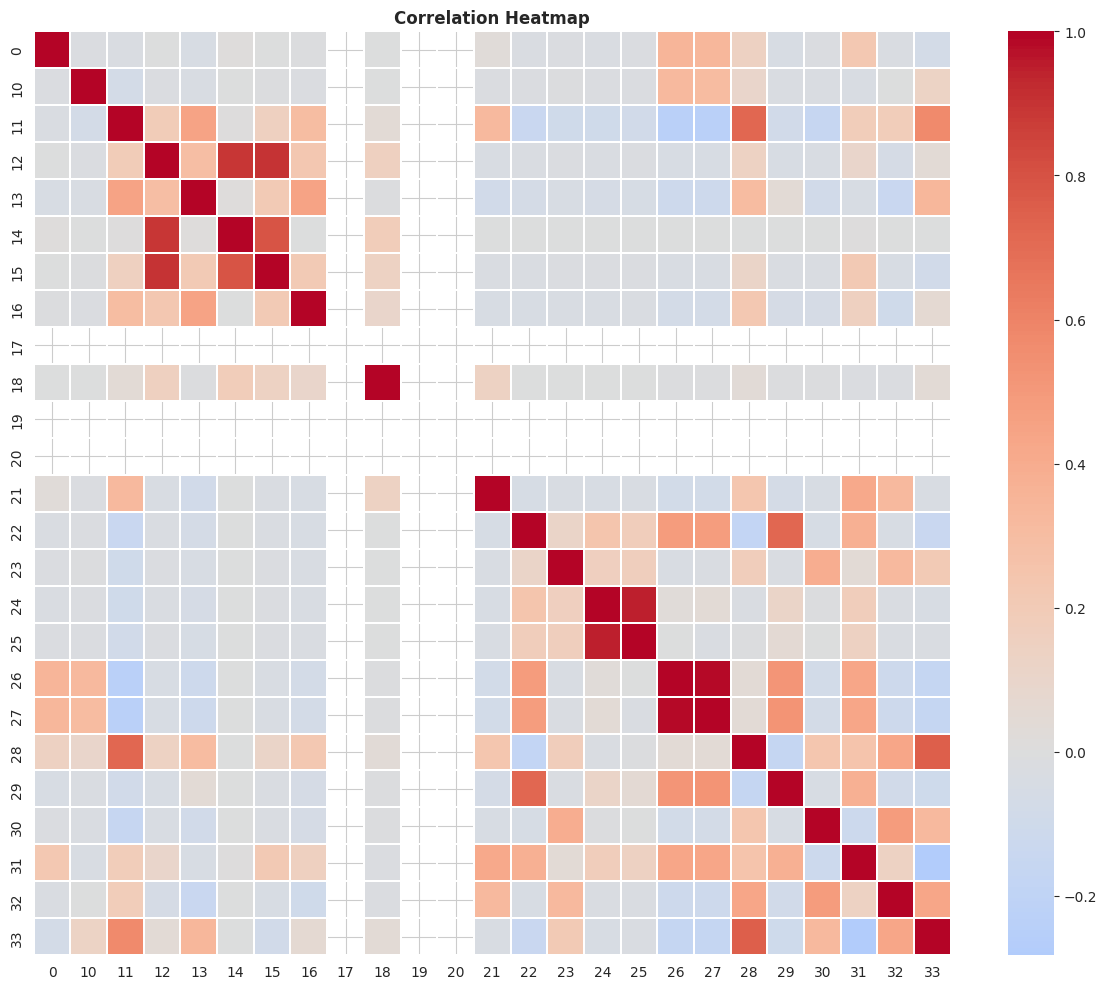

Running PCA...


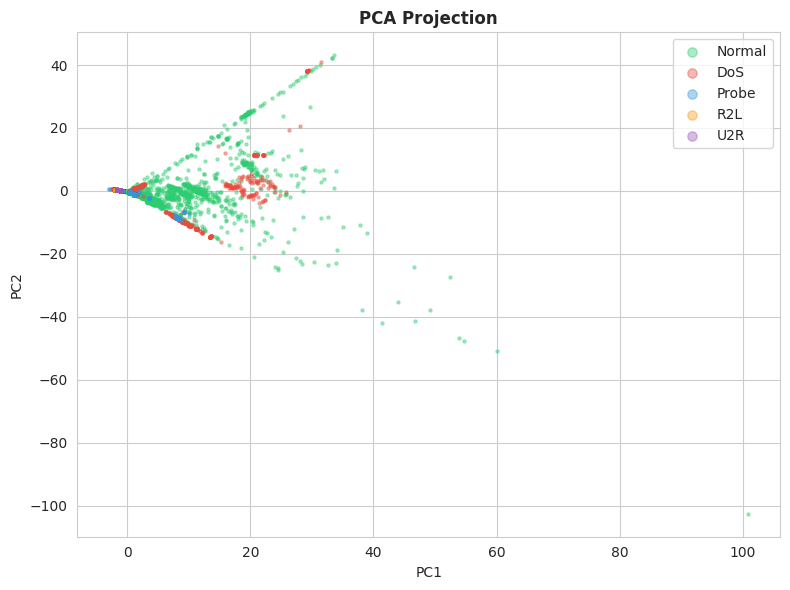


Generating cross-dataset plot...


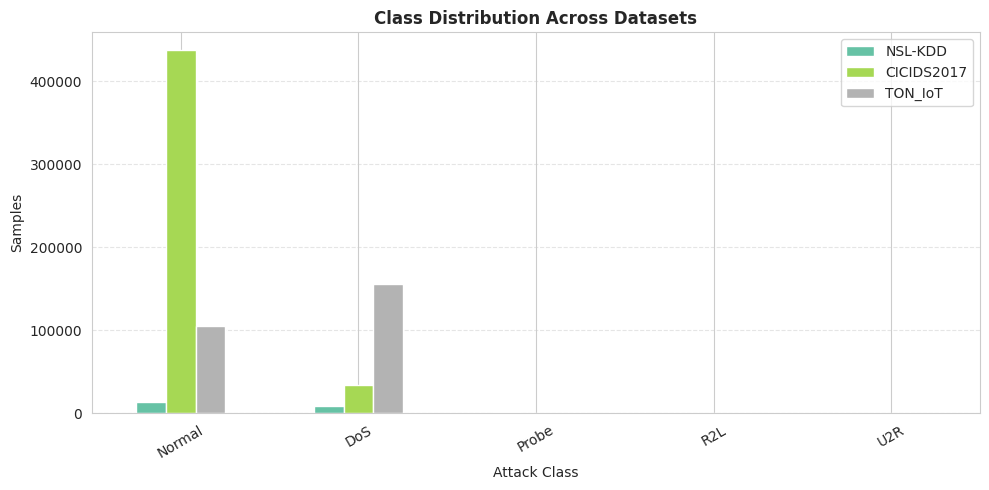


All EDA visualizations complete.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

# =========================
# LOAD
# =========================
df = pd.read_csv("Final_5Class_IDS.csv")

CLASSES = ["Normal","DoS","Probe","R2L","U2R"]

PALETTE = {
    "Normal":"#2ecc71",
    "DoS":"#e74c3c",
    "Probe":"#3498db",
    "R2L":"#f39c12",
    "U2R":"#9b59b6"
}

#  Ensure only numeric features
numeric_df = df.drop(columns=["label"]).select_dtypes(include=[np.number])

print("Dataset shape:", df.shape)

# =========================
# 1. CLASS DISTRIBUTION
# =========================
fig, ax = plt.subplots(figsize=(7, 4))

counts = df["label"].value_counts().reindex(CLASSES, fill_value=0)

bars = ax.bar(counts.index, counts.values,
              color=[PALETTE[c] for c in counts.index],
              edgecolor="white", width=0.6)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(counts.values)*0.01,
            f"{val:,}", ha="center", fontsize=10)

ax.set_title("Class Distribution — Balanced Dataset", fontweight="bold")
ax.set_xlabel("Attack Class")
ax.set_ylabel("Samples")

plt.tight_layout()
plt.savefig("fig_class_dist.png", dpi=300)
plt.show()

# =========================
# 2. FEATURE VARIANCE
# =========================
variances = numeric_df.var().sort_values(ascending=False)

top_k = min(50, len(variances))

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(range(top_k), variances.values[:top_k], alpha=0.4)
ax.plot(variances.values[:top_k], linewidth=1.5)

ax.set_title("Top Feature Variances", fontweight="bold")
ax.set_xlabel("Feature Rank")
ax.set_ylabel("Variance")

plt.tight_layout()
plt.savefig("fig_variance.png", dpi=300)
plt.show()

# =========================
# 3. CORRELATION HEATMAP
# =========================
subset = numeric_df.columns[:min(25, len(numeric_df.columns))]

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df[subset].corr(),
            cmap="coolwarm", center=0, linewidths=0.3)

plt.title("Correlation Heatmap", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_corr.png", dpi=300)
plt.show()

# =========================
# 4. PCA VISUALIZATION
# =========================
print("Running PCA...")

#  Safe sampling
sample_size = min(20000, len(df))
sample = df.sample(sample_size, random_state=42)

X_sample = sample.drop(columns=["label"]).select_dtypes(include=[np.number])
y_sample = sample["label"]

#  Handle NaN / inf
X_sample = X_sample.replace([np.inf, -np.inf], 0).fillna(0)

X_scaled = StandardScaler().fit_transform(X_sample)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    "PC1": pca_result[:,0],
    "PC2": pca_result[:,1],
    "label": y_sample.values
})

plt.figure(figsize=(8,6))

for cls in CLASSES:
    sub = df_pca[df_pca["label"] == cls]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"],
                    s=5, alpha=0.4,
                    color=PALETTE[cls],
                    label=cls)

plt.title("PCA Projection", fontweight="bold")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=3)

plt.tight_layout()
plt.savefig("fig_pca.png", dpi=300)
plt.show()

# =========================
# 5. CROSS-DATASET (SAFE)
# =========================
print("\nGenerating cross-dataset plot...")

def safe_counts(df):
    if df is None:
        return pd.Series([0]*len(CLASSES), index=CLASSES)
    return df["label"].value_counts().reindex(CLASSES, fill_value=0)

try:
    counts_dict = {
        "NSL-KDD": safe_counts(globals().get("clean_nsl")),
        "CICIDS2017": safe_counts(globals().get("clean_cic")),
        "TON_IoT": safe_counts(globals().get("clean_ton"))
    }

    df_plot = pd.DataFrame(counts_dict)

    df_plot.plot(kind="bar", figsize=(10,5), colormap="Set2")

    plt.title("Class Distribution Across Datasets", fontweight="bold")
    plt.xlabel("Attack Class")
    plt.ylabel("Samples")
    plt.xticks(rotation=30)
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig("fig_cross_dist.png", dpi=300)
    plt.show()

except Exception as e:
    print("Skipped cross-dataset plot:", e)

print("\nAll EDA visualizations complete.")

### **Analysis of Trust-Based Aggregation Across Clients**

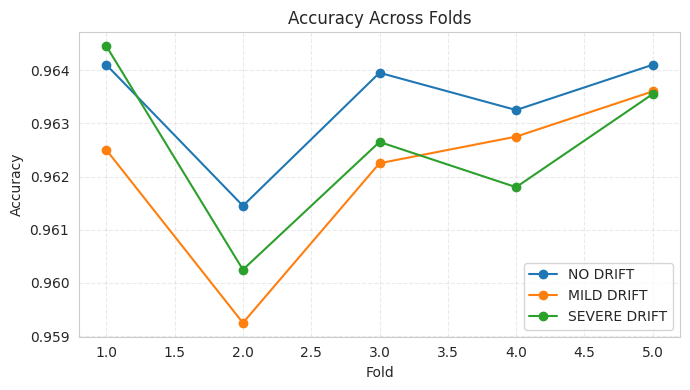

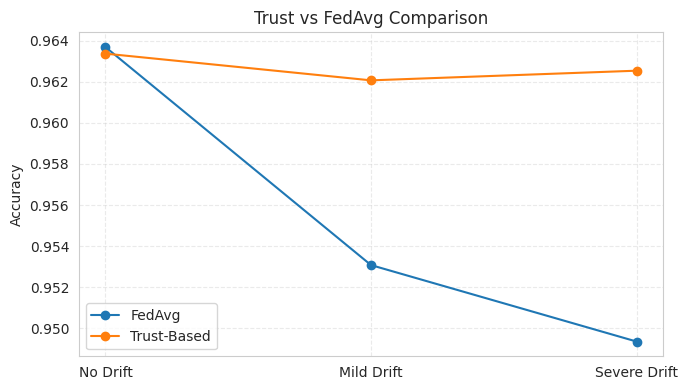

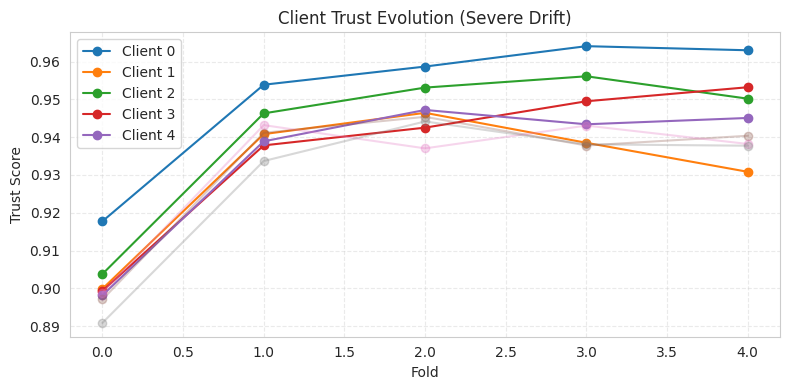


Running scalability analysis...
Testing 3 clients...

===== 3_CLIENTS =====
Client 0 Trust: 0.9162
Client 1 Trust: 0.9025
Client 2 Trust: 0.9072
Fold 1 → Trust=0.9642 | FedAvg=0.9601
Client 0 Trust: 0.9633
Client 1 Trust: 0.9395
Client 2 Trust: 0.9491
Fold 2 → Trust=0.9628 | FedAvg=0.9552
Client 0 Trust: 0.9665
Client 1 Trust: 0.9484
Client 2 Trust: 0.9519
Fold 3 → Trust=0.9651 | FedAvg=0.9591
Client 0 Trust: 0.9667
Client 1 Trust: 0.9458
Client 2 Trust: 0.9505
Fold 4 → Trust=0.9647 | FedAvg=0.9594
Client 0 Trust: 0.9683
Client 1 Trust: 0.9466
Client 2 Trust: 0.9477
Fold 5 → Trust=0.9658 | FedAvg=0.9580

FINAL:
Trust Mean: 0.9645
FedAvg Mean: 0.9584
Testing 5 clients...

===== 5_CLIENTS =====
Client 0 Trust: 0.9166
Client 1 Trust: 0.9021
Client 2 Trust: 0.9052
Client 3 Trust: 0.9063
Client 4 Trust: 0.8927
Fold 1 → Trust=0.9641 | FedAvg=0.9544
Client 0 Trust: 0.9578
Client 1 Trust: 0.9501
Client 2 Trust: 0.9436
Client 3 Trust: 0.9425
Client 4 Trust: 0.9366
Fold 2 → Trust=0.9617 | FedAv

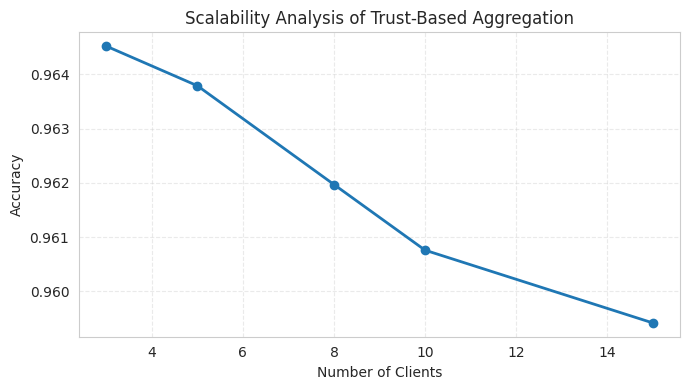

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

SCENARIOS = ["NO DRIFT","MILD DRIFT","SEVERE DRIFT"]

# ======================================================
# 1. ACCURACY PER FOLD (WITH LEGEND)
# ======================================================
plt.figure(figsize=(7,4))

for s in SCENARIOS:
    accs = RESULTS[s]["accs"]
    plt.plot(range(1, len(accs)+1), accs, marker='o', label=s)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Accuracy Across Folds")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ======================================================
# 2. TRUST vs FEDAVG
# ======================================================
trust_means = [RESULTS[s]["mean_acc"] for s in SCENARIOS]
fedavg_means = [RESULTS[s]["fedavg_mean_acc"] for s in SCENARIOS]

x = np.arange(len(SCENARIOS))

plt.figure(figsize=(7,4))

plt.plot(x, fedavg_means, marker='o', label="FedAvg")
plt.plot(x, trust_means, marker='o', label="Trust-Based")

plt.xticks(x, ["No Drift","Mild Drift","Severe Drift"])
plt.ylabel("Accuracy")
plt.title("Trust vs FedAvg Comparison")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ======================================================
# 3. TRUST CURVES (CLEAN LEGEND)
# ======================================================
trust_logs = RESULTS["SEVERE DRIFT"]["trust"]
num_clients = len(trust_logs[0])

plt.figure(figsize=(8,4))

for cid in range(num_clients):
    vals = [t[cid] for t in trust_logs]

    if cid < 5:
        plt.plot(vals, marker='o', label=f"Client {cid}")
    else:
        plt.plot(vals, marker='o', alpha=0.3)

plt.xlabel("Fold")
plt.ylabel("Trust Score")
plt.title("Client Trust Evolution (Severe Drift)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ======================================================
# 4. SCALABILITY ANALYSIS
# ======================================================
CLIENT_SETTINGS = [3, 5, 8, 10, 15]

scalability_results = []

print("\nRunning scalability analysis...")

for n in CLIENT_SETTINGS:
    print(f"Testing {n} clients...")

    NUM_CLIENTS = n
    run_experiment(f"{n}_CLIENTS", DRIFT_CFG["SEVERE DRIFT"])

    scalability_results.append(RESULTS[f"{n}_CLIENTS"]["mean_acc"])

plt.figure(figsize=(7,4))

plt.plot(CLIENT_SETTINGS, scalability_results, marker='o', linewidth=2)

plt.xlabel("Number of Clients")
plt.ylabel("Accuracy")
plt.title("Scalability Analysis of Trust-Based Aggregation")
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()